# PART5_Build_application_model

To build genomic prediction model to predict other population / to apply genomic breeding strategy,

prediction model which showed the highest accuracy using merging haplotype blocks in all CV were built.

In [ ]:
import ast
import gzip
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
sns.set()

%matplotlib inline
%config InlineBackend.figure_formats = {'png', 'retina'}

from modules.make_data_for_prediction import make_data, make_data_for_Tuning
from modules.tuning import tuning_LightGBM, tuning_Lasso, tuning_ElasticNet, tuning_RandomForest
from modules.training import train_Enet_for_app

# basic variables
family_list = pd.read_csv("../data/family_list.csv")
family = family_list.family.unique()
phenotype = "../data/phenotype_data/mean_phenotypes.csv"
CV=5
optuna_seed=1024
trait_names = ["LW_mean", "GN_mean", "LL_mean", "DTH_mean", "PN_mean", "Area.size.AS..mm2."]
HB_num_set = [3000, 2000, 1000, 900, 800, 700, 600, 500, 400, 300, 200, 100, 75, 50, 25, 10]
model = 'Enet'

# Calculate accuracy of the model based on merging selected haplotype blocks

## Extract 3000~10 Haplotype blocks based on average importances of all models in CVs
importance means feature importances, coefs, p-values calculated by model

In [23]:
genotype = pd.read_csv("../data/PART1_make_Haplotype_block/Haplotype_all_LD90.csv")

for trait_name in trait_names:
    with open('../data/PART5_Build_application_model/Compare_models_by_all_RILs_HBs_{}.pic.bin'.format(trait_name), 'rb') as p:
        summary = pickle.load(p)
    summary = pd.DataFrame(summary)
    for HB_num in HB_num_set:
        path = "../data/PART5_Build_application_model/selected_genotype/{}_{}_{}.csv.gz".format(trait_name, model, HB_num)                
        if model == "LGBM":
            imp = np.mean([np.mean(i, axis=0) for i in summary.loc[(summary.iloc[:, 0] == trait_name) & (summary.iloc[:, 2] == "LGBM"), 6].values], axis=0)
        else:
            imp = np.mean(summary.loc[(summary.iloc[:, 0] == trait_name) & (summary.iloc[:, 2] == model), 6].values, axis=0)
        selected_indices = np.argsort(np.abs(imp))[::-1][:HB_num]
        genotype.loc[np.sort(selected_indices), :].to_csv(path, index=None)

## Parameter tuning

In [ ]:
def make_data_for_Tuning_selected_HBs(model, HB_num, family, family_list, trait_name, phenotype, CV):
    genotype = "../data/PART5_Build_application_model/selected_genotype/{}_{}_{}.csv.gz".format(trait_name, model, HB_num)                
    test_data, train_data, position_data = make_data(family, family_list, trait_name, genotype, phenotype, CV, seed=1024, plot=False)
    return test_data, train_data

for trait_name in trait_names:
    Enet_params = []
    print(trait_name)
    for HB_num in HB_num_set:
        print(HB_num)
        
        # Tuning Enet
        test_data, train_data = make_data_for_Tuning_selected_HBs("Enet", HB_num, family, family_list, trait_name, phenotype, CV)
        for i in range(CV):
            train_data_CVn = train_data[i]
            X = train_data_CVn[0]; y = train_data_CVn[1]
            Enet_params.append([trait_name, HB_num, i, tuning_ElasticNet(X, y)])
    pd.DataFrame(Enet_params).to_csv("../data/PART5_Build_application_model/Enet_selected_HBs_{}_params.csv".format(trait_name))

## Train models using selected HBs

In [ ]:
model = "Enet"
summary = []
for trait_name in trait_names:
    for HB_num in HB_num_set:
        print(trait_name, model, HB_num)
        genotype = "../data/PART5_Build_application_model/selected_genotype/{}_{}_{}.csv".format(trait_name, model, HB_num)    
        test_data, train_data, position_data = make_data(family, family_list, trait_name, genotype, phenotype, CV, seed=1024, plot=False, log=False)

        for i in range(CV):
            print("CV{}".format(i))
            # parameters
            params = pd.read_csv("../data/PART5_Build_application_model/{}_selected_HBs_{}_params.csv".format(model, trait_name), index_col=0)
            params.columns = ["trait", "HB_num", "CV", "params"]
            params = ast.literal_eval(params.loc[(params["trait"] == trait_name) & (params["CV"] == i) & (params["HB_num"] == HB_num), "params"].values[0])
            tmp_test_data = test_data[i]
            tmp_train_data = train_data[i]

            test_pred, r2, acc_RIL, imps = train_Enet_for_app(tmp_test_data, tmp_train_data, params)
            summary.append([trait_name, HB_num, model, i, test_pred, r2, acc_RIL, imps])

with open('../data/PART5_Build_application_model/Compare_models_by_all_RILs_selected_HBs.pic.bin', 'wb') as p:
    pickle.dump(summary, p)

## Select best haplotype set for each trait using ElasticNet

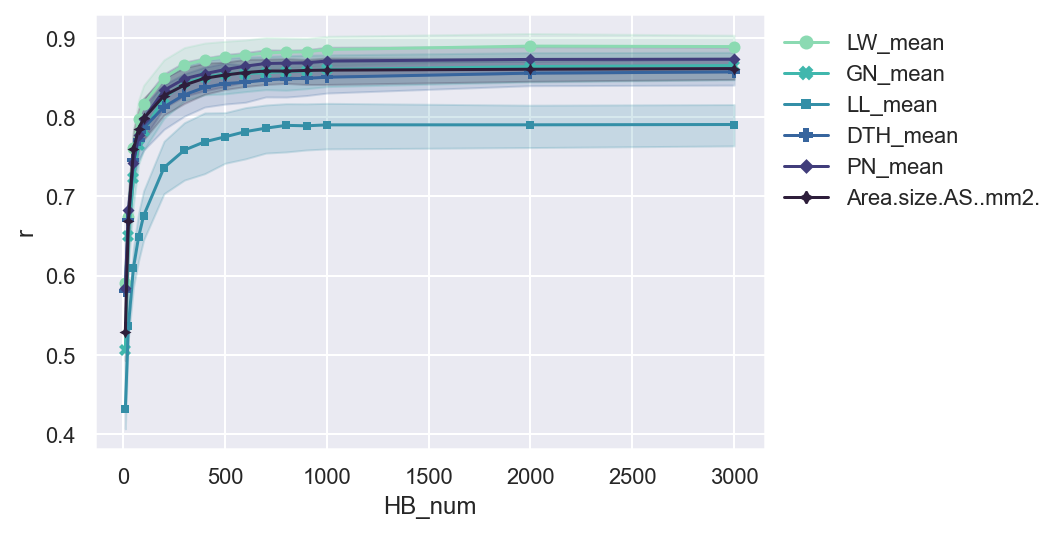

In [4]:
with open('../data/PART5_Build_application_model/Compare_models_by_all_RILs_selected_HBs.pic.bin', 'rb') as p:
    summary = pickle.load(p)
summary = pd.DataFrame(summary)
Enet_summary = summary.iloc[:, [0,1,2,3,5]]
Enet_summary.columns = ["trait", "HB_num", "model", "CV", "r"]
palette = sns.color_palette("mako_r", 6)
ax = sns.lineplot(data=Enet_summary, x="HB_num", y="r", hue="trait", style="trait", palette=palette, markers=True, dashes=False, markeredgewidth=0)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title=None, frameon=False,)
plt.show()

In [4]:
best_HB_num = pd.DataFrame()
for trait_name in trait_names:
    trait_summary = Enet_summary[Enet_summary.trait == trait_name]
    trait_summary = trait_summary.groupby(["trait", "HB_num", "model"]).mean().reset_index()
    best_HB_num = pd.concat([best_HB_num, trait_summary.sort_values(by="r", ascending=False).iloc[0, :].to_frame().T])
best_HB_num

,trait,HB_num,model,CV,r
11,LW_mean,800,Enet,2.0,0.929925
12,GN_mean,900,Enet,2.0,0.912034
13,LL_mean,1000,Enet,2.0,0.861674
8,DTH_mean,500,Enet,2.0,0.899664
13,PN_mean,1000,Enet,2.0,0.915041
9,Area.size.AS..mm2.,600,Enet,2.0,0.89662
